### Importing pandas

In [1]:
import pandas as pd
import numpy as np

### Loading data from csv file

In [2]:
df=pd.read_csv("sales_data.csv")

### Printing shape & size of dataset

In [76]:
print(f"Number of rows in the DataFrame: {df.shape[0]}")
print(f"Number of columns in the DataFrame: {df.shape[1]}")

Number of rows in the DataFrame: 100
Number of columns in the DataFrame: 7


### Printing other information

In [77]:
print("Column names in the DataFrame:")
for col in df.columns:
    print(col)
print("\nDataFrame Info:")
print(df.info())

Column names in the DataFrame:
Date
Product
Quantity
Price
Customer_ID
Region
Total_Sales

DataFrame Info:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         100 non-null    string 
 1   Product      100 non-null    string 
 2   Quantity     100 non-null    Int64  
 3   Price        100 non-null    Int64  
 4   Customer_ID  100 non-null    string 
 5   Region       100 non-null    string 
 6   Total_Sales  100 non-null    float64
dtypes: Int64(2), float64(1), string(4)
memory usage: 5.8 KB
None


In [79]:
print("Data types of each columns:\n")
print(df.dtypes)

Data types of each columns:

Date            string
Product         string
Quantity         Int64
Price            Int64
Customer_ID     string
Region          string
Total_Sales    float64
dtype: object


### Finding if any values are missing

In [ ]:
print(df.isnull().sum())

Date           0
Product        0
Quantity       0
Price          0
Customer_ID    0
Region         0
Total_Sales    0
dtype: int64


In [35]:
print(df.duplicated(subset=["Product"]).sum())

95


### Quantity analysis

In [81]:
avg_quantity=df.iloc[:,2].mean()
print(f"Average amount of quantity sold: {avg_quantity}")
med_quantity=df.iloc[:,2].median()
print(f"Median amount of quantity sold: {med_quantity}\n")
# print(df.iloc[:,2].mode())

Average amount of quantity sold: 4.78
Median amount of quantity sold: 5.0



### Price analysis

In [98]:
avg_sold_items=df.iloc[:,3].mean()
print(f"Average price of sold items: ₹{avg_sold_items:.2f}")
med_sold_items=df.iloc[:,3].median()
print(f"Median price of sold items: ₹{med_sold_items:.2f}\n")
std_dev_sold_items=df.iloc[:,3].std()
print(f"Standard deviation of price of sold items: ₹{std_dev_sold_items:.3f}\n")

Average price of sold items: ₹25808.51
Median price of sold items: ₹24192.00

Standard deviation of price of sold items: ₹13917.630



### Sales analysis

In [97]:
print(f"Data type of Total_Sales: {df['Total_Sales'].dtype}")
df["Total_Sales"]=pd.to_numeric(df["Total_Sales"], errors='coerce')
print(f"Data type of Total_Sales after conversion: {df['Total_Sales'].dtype}\n")

avg_price=df["Total_Sales"].mean()
print(f"Average sales: ₹{avg_price:.2f}")
med_price=df["Total_Sales"].median()
print(f"Median sales: ₹{med_price:.2f}")
std_dev_total_sales=df["Total_Sales"].std()
print(f"Standard deviation of sales: ₹{std_dev_total_sales:.3f}\n")

Data type of Total_Sales: float64
Data type of Total_Sales after conversion: float64

Average sales: ₹123650.48
Median sales: ₹97955.50
Standard deviation of sales: ₹100161.085



### Overall analysis

In [ ]:
price_per_item=avg_sold_items/avg_quantity
print(f"Average price per sold item: ₹{price_per_item:.3f}\n")

med_per_item=med_sold_items/med_quantity
print(f"Median price per sold item: ₹{med_per_item:.3f}\n")

std_dev_per_item=std_dev_sold_items/avg_quantity
print(f"Standard deviation of price per sold item: ₹{std_dev_per_item:.3f}\n")

total_revenue=df['Total_Sales'].sum()
print(f'Total Revenue: ₹{total_revenue:.2f}')

Average price per sold item: ₹5399.270

Median price per sold item: ₹4838.400

Standard deviation of price per sold item: ₹2911.638

Total Revenue: ₹12365048.00


### Regional Sale insights

In [99]:
max_value=df["Total_Sales"].max()
print(f"Maximum sales: ₹{max_value:.2f}")

Maximum sales: ₹373932.00


In [108]:
result=df.groupby("Region")["Total_Sales"].sum()
print(f"Region-wise total sales:{result}\n")
print(f"Maximum region-wise sales: ₹{result.max():.2f}")

Region-wise total sales:Region
East     2519639.0
North    3983635.0
South    3737852.0
West     2123922.0
Name: Total_Sales, dtype: float64

Maximum region-wise sales: ₹3983635.00


In [115]:
s=pd.Series(result)
idx=s.idxmax()
print(f"{idx} has the highest sales of ₹{s.max():.2f}")

North has the highest sales of ₹3983635.00


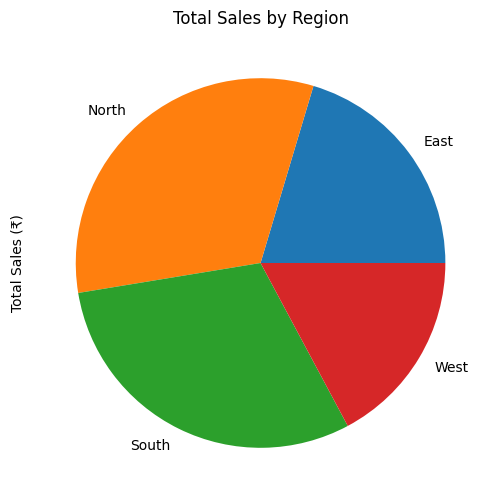

In [122]:
import matplotlib.pyplot as plt
result.plot(kind='pie', title='Total Sales by Region', xlabel='Region', ylabel='Total Sales (₹)', figsize=(10, 6))
plt.show()